## How this data was generated

```bash
cd camonitor-cliff/
python3 run_channel_cost_test.py --scenarios B,C --out-dir ../docs/camonitor-cliff/channel_cost
```

Defaults used: `--n-servers 10 --pvs-per-server 500 --pvs-per-buffer 20 --round-interval-s 0.3`
(10 servers × 500 PVs = 5,000 channels per scenario). `--scenarios B,C` is the script's default
and can be omitted. Client RSS (in addition to server RSS) is polled by the orchestrator process
itself, from the client subprocess's own PID -- the client runs with `--no-watcher`, so there's no
in-client `CacheWatcher` doing this.

# Channel cost — results

Loads the two scenario CSVs written by `run_channel_cost_test.py` (in `camonitor-cliff/`) and
compares the server-side memory cost of a leftover CA channel at real scale (5,000 channels,
spread across 10 mock IOCs — see that script's module docstring for why one server alone can't
be pushed this far).

- **B** — `epics.PV(pvname, auto_monitor=False)`, channel left open (never `clear_channel()`d).
- **C** — same, plus an explicit `epics.ca.clear_channel()` right after `disconnect()`.

See `../run_comparison/results.ipynb` for the original (smaller-scale) three-way A/B/C comparison,
and `../../../camonitor-cliff/README.md` for the full write-up.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

HERE = Path.cwd()
COLORS = {"B": "tab:orange", "C": "tab:green"}
LABELS = {
    "B": "B — auto_monitor=False",
    "C": "C — B + clear_channel()",
}

In [2]:
data = {
    label: pd.read_csv(HERE / f"results_{label}.csv")
    for label in ["B", "C"]
}
for label, df in data.items():
    print(label, df.shape, f"{df['elapsed_s'].iloc[0]:.1f}s -> {df['elapsed_s'].iloc[-1]:.1f}s")

B (739, 4) 0.0s -> 739.1s
C (945, 4) 0.0s -> 945.4s


## Memory

In [3]:
def summarize(label, df):
    # Settled baseline: server RSS jumps during the first ~1-2s of
    # asyncio/scan-callback warm-up, independent of any client channels --
    # using the raw t=0 sample would attribute that warm-up cost to
    # channels. Real plateau: the elapsed_s where channels_touched_so_far
    # first reaches its max (all channels touched), not assumed from
    # configured round timing (per-round time grows substantially with
    # total channel count already open at this scale).
    baseline = df[df["elapsed_s"] >= 2.0].iloc[0]
    total_channels = df["channels_touched_so_far"].max()
    plateau = df[df["channels_touched_so_far"] == total_channels].iloc[0]
    final = df.iloc[-1]
    server_delta = plateau["server_mem_rss_mb"] - baseline["server_mem_rss_mb"]
    client_delta = plateau["client_mem_rss_mb"] - baseline["client_mem_rss_mb"]
    server_kb = (server_delta / total_channels) * 1024 if total_channels else 0
    client_kb = (client_delta / total_channels) * 1024 if total_channels else 0
    return {
        "scenario": LABELS[label],
        "total_channels": int(total_channels),
        "server_baseline_mb": round(baseline["server_mem_rss_mb"], 1),
        "server_plateau_mb": round(plateau["server_mem_rss_mb"], 1),
        "server_delta_mb": round(server_delta, 2),
        "server_kb_per_channel": round(server_kb, 2),
        "client_baseline_mb": round(baseline["client_mem_rss_mb"], 1),
        "client_plateau_mb": round(plateau["client_mem_rss_mb"], 1),
        "client_delta_mb": round(client_delta, 2),
        "client_kb_per_channel": round(client_kb, 2),
    }

summary = pd.DataFrame([summarize(label, df) for label, df in data.items()]).set_index("scenario")
summary

,total_channels,server_baseline_mb,server_plateau_mb,server_delta_mb,server_kb_per_channel,client_baseline_mb,client_plateau_mb,client_delta_mb,client_kb_per_channel
scenario,,,,,,,,,
B — auto_monitor=False,5000,1133.8,1144.1,10.29,2.11,39.2,158.8,119.59,24.49
C — B + clear_channel(),5000,1133.8,1139.3,5.43,1.11,39.0,39.2,0.17,0.03


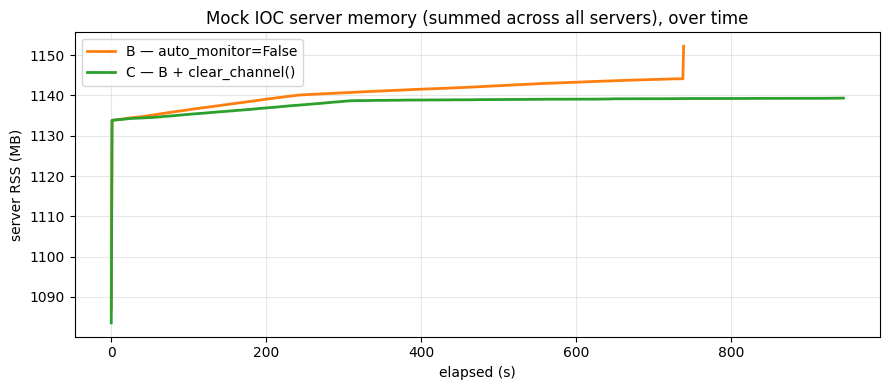

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, df in data.items():
    ax.plot(df["elapsed_s"], df["server_mem_rss_mb"], label=LABELS[label], color=COLORS[label], lw=2)
ax.set_xlabel("elapsed (s)")
ax.set_ylabel("server RSS (MB)")
ax.set_title("Mock IOC server memory (summed across all servers), over time")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

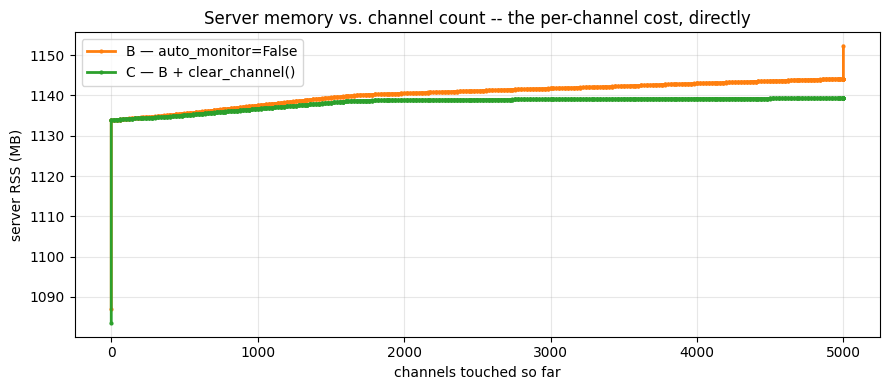

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, df in data.items():
    ax.plot(df["channels_touched_so_far"], df["server_mem_rss_mb"], label=LABELS[label], color=COLORS[label], lw=2, marker="o", ms=2)
ax.set_xlabel("channels touched so far")
ax.set_ylabel("server RSS (MB)")
ax.set_title("Server memory vs. channel count -- the per-channel cost, directly")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

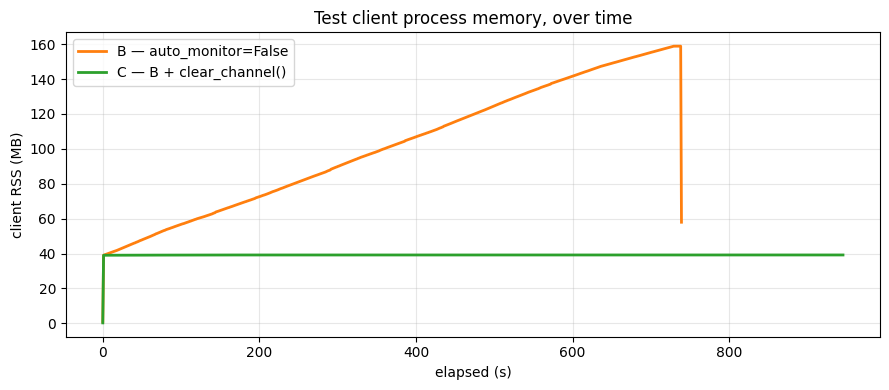

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, df in data.items():
    ax.plot(df["elapsed_s"], df["client_mem_rss_mb"], label=LABELS[label], color=COLORS[label], lw=2)
ax.set_xlabel("elapsed (s)")
ax.set_ylabel("client RSS (MB)")
ax.set_title("Test client process memory, over time")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()